In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import time
import joblib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

from sklearn.naive_bayes import MultinomialNB

from src.preprocessing.cleaner import preprocess_for_tfidf
from src.features.tfidf import TFIDFVectorizer

In [3]:
train_df = pd.read_csv("../data/interim/train_split.csv")
valid_df = pd.read_csv("../data/interim/valid_split.csv")

C:\Users\fam-01\AppData\Local\Temp\ipykernel_22552\3517047404.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../data/interim/train_split.csv")
C:\Users\fam-01\AppData\Local\Temp\ipykernel_22552\3517047404.py:2: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  valid_df = pd.read_csv("../data/interim/valid_split.csv")


In [4]:
train_df["clean_text"] = train_df["reviewText"].fillna("").apply(preprocess_for_tfidf)
valid_df["clean_text"] = valid_df["reviewText"].fillna("").apply(preprocess_for_tfidf)

In [6]:
tfidf = TFIDFVectorizer.load("../artifacts/vectorizers/tfidf.joblib")

In [7]:
X_train = tfidf.transform(train_df["clean_text"])
X_valid = tfidf.transform(valid_df["clean_text"])

In [8]:
y_train = train_df["overall"]
y_valid = valid_df["overall"]

In [9]:
start = time.time()

model = MultinomialNB()

model.fit(X_train, y_train)

training_time = time.time() - start

print(f"Training Time: {training_time:.2f} sec")

Training Time: 0.88 sec


In [10]:
y_pred = model.predict(X_valid)

In [11]:
accuracy = accuracy_score(y_valid, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.6524


In [12]:
print(
    classification_report(
        y_valid,
        y_pred,
    )
)

              precision    recall  f1-score   support

           1       0.57      0.65      0.61     16590
           2       0.45      0.05      0.08     11351
           3       0.39      0.10      0.16     16248
           4       0.47      0.28      0.35     31303
           5       0.70      0.95      0.81     92297

    accuracy                           0.65    167789
   macro avg       0.51      0.41      0.40    167789
weighted avg       0.60      0.65      0.59    167789



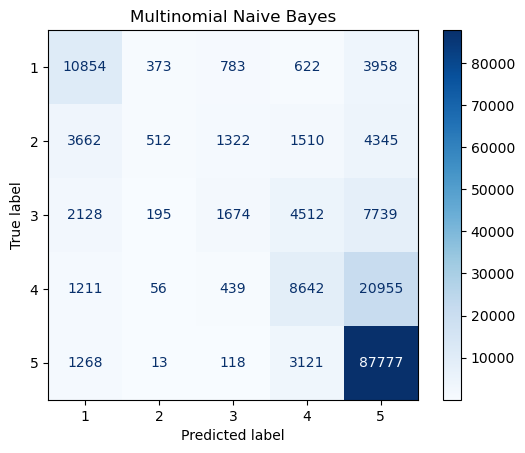

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    cmap="Blues",
)

plt.title("Multinomial Naive Bayes")
plt.show()

In [14]:
pd.Series(y_pred).value_counts().sort_index()

1     19123
2      1149
3      4336
4     18407
5    124774
Name: count, dtype: int64

In [15]:
model.feature_log_prob_.shape

(5, 50000)

In [16]:
models_dir = Path("../artifacts/models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    model,
    models_dir / "naive_bayes.joblib",
)

['..\\artifacts\\models\\naive_bayes.joblib']

In [17]:
model_path = models_dir / "naive_bayes.joblib"

print(f"Model size: {model_path.stat().st_size / 1024 / 1024:.2f} MB")

Model size: 3.82 MB


Multinomial Naive Bayes was trained using the same TF-IDF features as the previous linear models. The results will be compared against Logistic Regression and Linear SVM to establish a complete set of classical NLP baselines.